# Clustering Visuals

Quick visuals for methodology, segment sizes, and feature heatmap.

## Visual 1: Lifecycle-first methodology flow

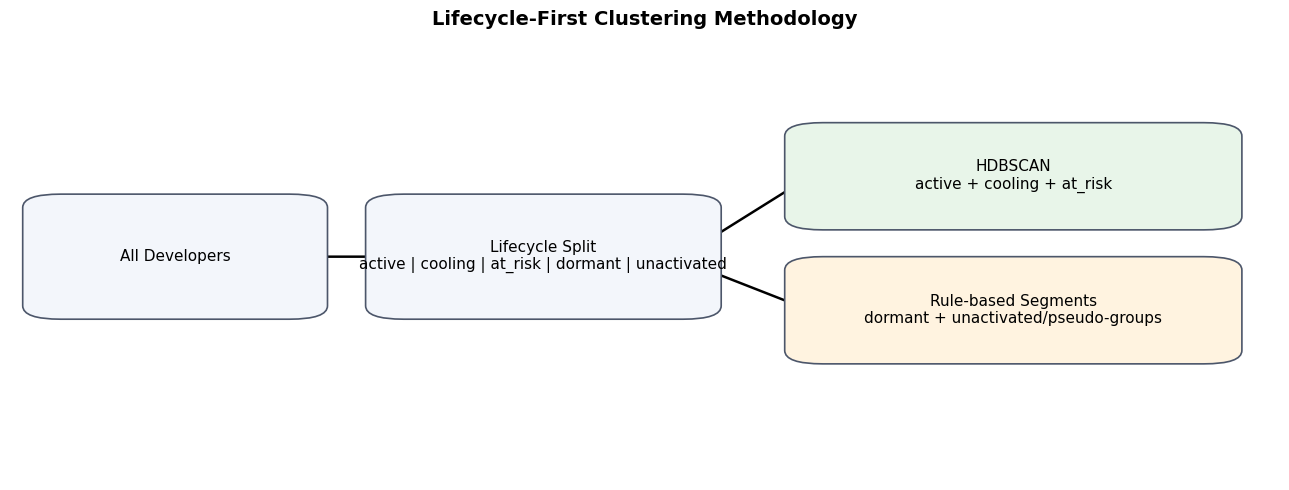

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

def box(x, y, w, h, text, fc="#f3f6fb"):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.03",
                       linewidth=1.2, edgecolor="#4c566a", facecolor=fc, zorder=3)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11, wrap=True, zorder=4)

box(0.03, 0.38, 0.2, 0.24, "All Developers")
box(0.30, 0.38, 0.24, 0.24, "Lifecycle Split\nactive | cooling | at_risk | dormant | unactivated")
box(0.63, 0.58, 0.32, 0.20, "HDBSCAN\nactive + cooling + at_risk", fc="#e8f5e9")
box(0.63, 0.28, 0.32, 0.20, "Rule-based Segments\ndormant + unactivated/pseudo-groups", fc="#fff3e0")

ax.annotate("", xy=(0.30, 0.50), xytext=(0.23, 0.50), arrowprops=dict(arrowstyle="->", lw=1.8), zorder=1)
ax.annotate("", xy=(0.63, 0.68), xytext=(0.54, 0.52), arrowprops=dict(arrowstyle="->", lw=1.8), zorder=1)
ax.annotate("", xy=(0.63, 0.38), xytext=(0.54, 0.48), arrowprops=dict(arrowstyle="->", lw=1.8), zorder=1)

plt.title("Lifecycle-First Clustering Methodology", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

## Visual 2: Final segment size chart

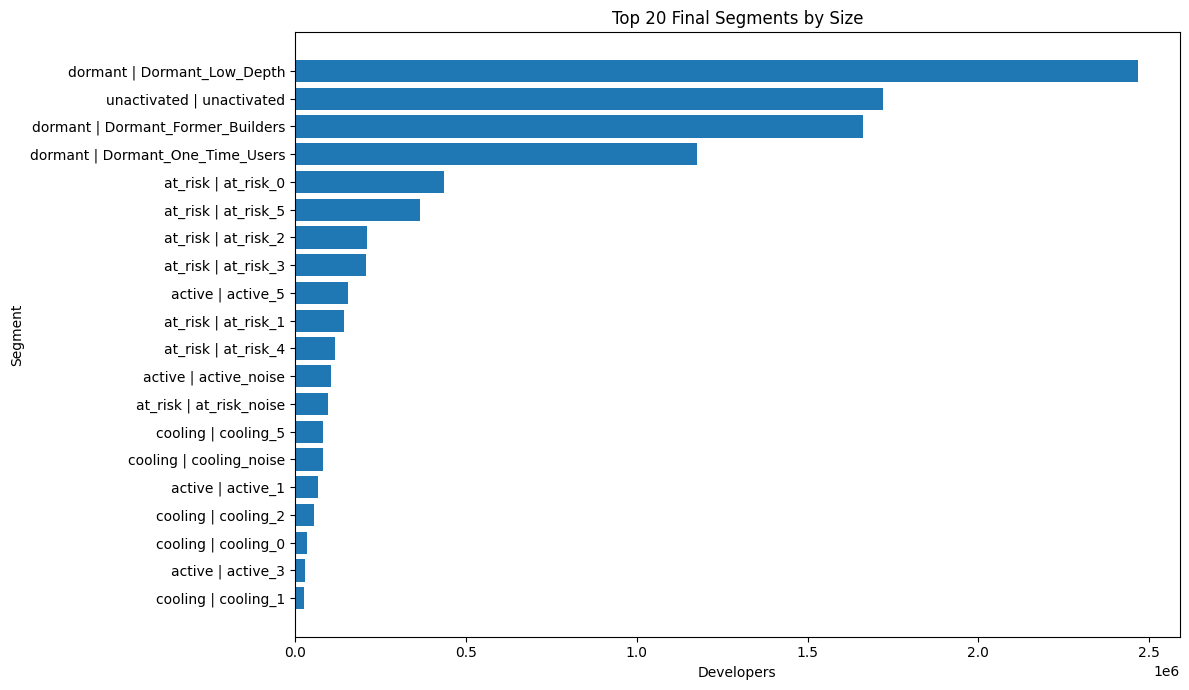

,stratum,n_developers
0,dormant,5304852
1,unactivated,1721230
2,at_risk,1580877
3,active,418049
4,cooling,356500


In [14]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("developer_project.duckdb", read_only=True)

final_table = "dev_lifecycle_cluster_membership_v11_final"

exists = con.execute(f"""
SELECT COUNT(*)
FROM information_schema.tables
WHERE table_schema='main' AND table_name='{final_table}'
""").fetchone()[0] > 0

if not exists:
    raise RuntimeError(f"{final_table} not found. Rebuild V11 final membership first.")

size_df = con.execute(f"""
SELECT
    stratum,
    cluster_key,
    COUNT(*) AS n_developers
FROM {final_table}
GROUP BY 1,2
ORDER BY n_developers DESC
""").fetchdf()

top_n = 20
plot_df = size_df.head(top_n).copy()
plot_df["label"] = plot_df["stratum"] + " | " + plot_df["cluster_key"]

plt.figure(figsize=(12, 7))
plt.barh(plot_df["label"][::-1], plot_df["n_developers"][::-1])
plt.xlabel("Developers")
plt.ylabel("Segment")
plt.title(f"Top {top_n} Final Segments by Size")
plt.tight_layout()
plt.show()

stratum_df = con.execute(f"""
SELECT stratum, COUNT(*) AS n_developers
FROM {final_table}
GROUP BY 1
ORDER BY n_developers DESC
""").fetchdf()
display(stratum_df)

con.close()

## Visual 3: Cluster interpretation heatmap

dev_profile_cluster_summary_v11 not found; computing heatmap inputs from dev_lifecycle_cluster_membership_v11_final + dev_profile_final_v4.


/var/folders/kk/czyhbh5961ggwtk14x632d900000gq/T/ipykernel_25912/2210933085.py:79: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_df = heat_df[heat_df["cluster_key"].str.contains(r"^(active|cooling|at_risk)_", regex=True)].copy()


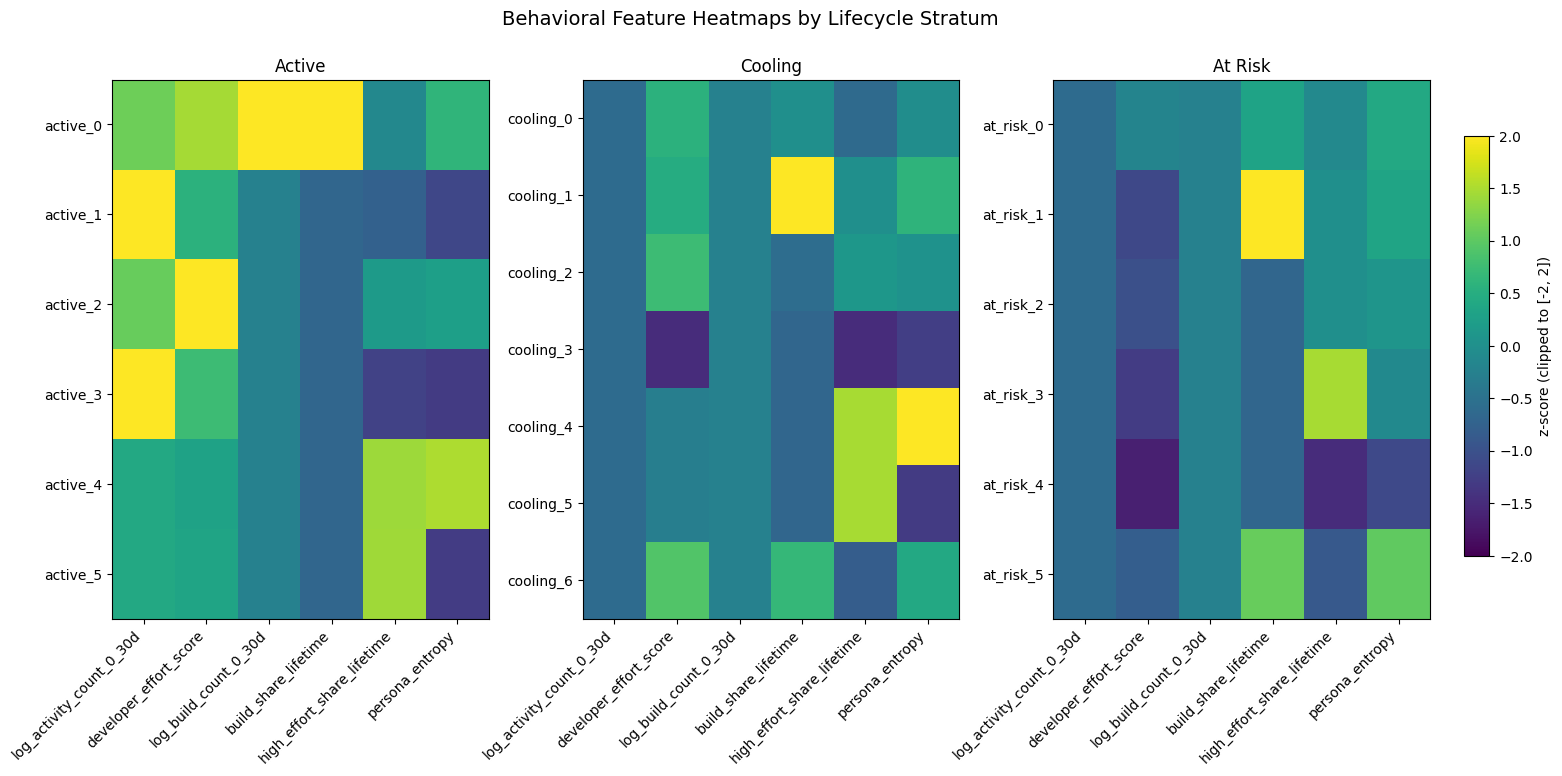

In [15]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("developer_project.duckdb", read_only=True)

profile_table = "dev_profile_cluster_summary_v11"
final_table = "dev_lifecycle_cluster_membership_v11_final"
profile_fallback_table = "dev_profile_final_v4"

features = [
    "log_activity_count_0_30d",
    "developer_effort_score",
    "log_build_count_0_30d",
    "build_share_lifetime",
    "high_effort_share_lifetime",
    "persona_entropy",
]

profile_exists = con.execute(f"""
SELECT COUNT(*)
FROM information_schema.tables
WHERE table_schema='main' AND table_name='{profile_table}'
""").fetchone()[0] > 0

if profile_exists:
    cols = con.execute(f"""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_name='{profile_table}'
    """).fetchdf()["column_name"].tolist()

    missing = [c for c in ["cluster_key"] + features if c not in cols]
    if missing:
        raise RuntimeError(f"Missing columns in {profile_table}: {missing}")

    heat_df = con.execute(f"""
    SELECT cluster_key, {", ".join(features)}
    FROM {profile_table}
    """).fetchdf()
else:
    # Fallback: build cluster-level means from final membership + profile table
    final_exists = con.execute(f"""
    SELECT COUNT(*)
    FROM information_schema.tables
    WHERE table_schema='main' AND table_name='{final_table}'
    """).fetchone()[0] > 0
    base_exists = con.execute(f"""
    SELECT COUNT(*)
    FROM information_schema.tables
    WHERE table_schema='main' AND table_name='{profile_fallback_table}'
    """).fetchone()[0] > 0

    if not (final_exists and base_exists):
        raise RuntimeError(
            f"Neither {profile_table} exists nor fallback source tables are available. "
            f"Need {final_table} and {profile_fallback_table}."
        )

    print(f"{profile_table} not found; computing heatmap inputs from {final_table} + {profile_fallback_table}.")
    heat_df = con.execute(f"""
    SELECT
        m.cluster_key,
        AVG(CAST(p.log_activity_count_0_30d AS DOUBLE)) AS log_activity_count_0_30d,
        AVG(CAST(p.developer_effort_score AS DOUBLE)) AS developer_effort_score,
        AVG(CAST(p.log_build_count_0_30d AS DOUBLE)) AS log_build_count_0_30d,
        AVG(CAST(p.build_share_lifetime AS DOUBLE)) AS build_share_lifetime,
        AVG(CAST(p.high_effort_share_lifetime AS DOUBLE)) AS high_effort_share_lifetime,
        AVG(CAST(p.persona_entropy AS DOUBLE)) AS persona_entropy
    FROM {final_table} m
    JOIN {profile_fallback_table} p
      ON CAST(m.developer_id AS VARCHAR) = CAST(p.developer_id AS VARCHAR)
    GROUP BY 1
    ORDER BY 1
    """).fetchdf()

# Focus on lifecycle HDBSCAN strata only and split into 3 small heatmaps
plot_df = heat_df[heat_df["cluster_key"].str.contains(r"^(active|cooling|at_risk)_", regex=True)].copy()

# Optional: hide noise rows in main slide visual
plot_df = plot_df[~plot_df["cluster_key"].str.endswith("_noise")].copy()

# Keep deterministic ordering within each stratum
plot_df = plot_df.sort_values("cluster_key").reset_index(drop=True)

if plot_df.empty:
    raise RuntimeError("No active/cooling/at_risk cluster rows available for heatmap.")

X = plot_df[features].copy()
Xz = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
Xz = Xz.fillna(0.0).clip(-2, 2)
plot_df[features] = Xz

strata_order = ["active", "cooling", "at_risk"]
fig, axes = plt.subplots(1, 3, figsize=(17, 7), sharex=True)

last_im = None
for i, stratum in enumerate(strata_order):
    ax = axes[i]
    sub = plot_df[plot_df["cluster_key"].str.startswith(f"{stratum}_")].copy()

    if sub.empty:
        ax.axis("off")
        ax.set_title(f"{stratum} (no rows)")
        continue

    mat = sub[features].values
    last_im = ax.imshow(mat, aspect="auto", vmin=-2, vmax=2)
    ax.set_title(stratum.replace("_", " ").title())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, rotation=45, ha="right")
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["cluster_key"])

# Reserve space on the right for one shared colorbar
fig.subplots_adjust(right=0.90, wspace=0.25)
if last_im is not None:
    cax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label("z-score (clipped to [-2, 2])")

fig.suptitle("Behavioral Feature Heatmaps by Lifecycle Stratum", fontsize=14)
plt.show()

con.close()